In [26]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

from dotenv import load_dotenv
import operator

from langgraph.checkpoint.memory import MemorySaver

In [27]:
load_dotenv()  # Load environment variables from .env file

True

In [28]:
llm =  ChatGroq(
    model="openai/gpt-oss-120b")


In [29]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [30]:
def chat_node(state: ChatState):
    messages=state['messages']
    response=llm.invoke(messages)
    return {'messages':[response]}

In [31]:


checkpoint = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpoint)

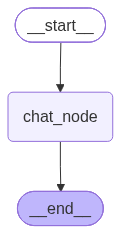

In [32]:
chatbot

In [48]:

thread_id = "2"
initial_state={
    'messages':[HumanMessage(content='what is my name?')]
}
config1 = {'configurable':{'thread_id':thread_id}}
response1 = chatbot.invoke(initial_state, config=config1)
   

In [49]:
response1['messages'][-1].content

'Your name is\u202fAmo.'

In [50]:
chatbot.get_state(config=config1)

StateSnapshot(values={'messages': [HumanMessage(content='what is mu name?', additional_kwargs={}, response_metadata={}, id='e23493bc-b420-4398-802a-91c983cb846a'), AIMessage(content='I don’t actually know your name—could you let me know what you’d like to be called?', additional_kwargs={'reasoning_content': 'The user asks "what is mu name?" Likely a typo: "what is my name?" The user hasn\'t provided their name. We cannot guess. According to policy, we should respond that we don\'t know the name and ask for clarification. So answer: I don\'t know your name; could you tell me?'}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 76, 'total_tokens': 170, 'completion_time': 0.195393134, 'completion_tokens_details': {'reasoning_tokens': 64}, 'prompt_time': 0.003487057, 'prompt_tokens_details': None, 'queue_time': 0.061150038, 'total_time': 0.198880191}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_1d982b31b2', 'service_tier': 'on_demand', 'finish

In [ ]:


while(True):
    user_message = input('Type Here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
    print('AI:', response['messages'][-1].content)

User: hi
AI: Hello! How can I help you today?
User: my name is pavi
AI: Nice to meet you, Pavi! How can I assist you today?
User: tell me capital of australia
AI: The capital of Australia is **Canberra**. It’s located in the Australian Capital Territory (ACT) and serves as the seat of the federal government, housing Parliament House, the High Court, and many national institutions. If you’d like to know more about Canberra—its history, attractions, or anything else—just let me know!
User: whats the time there
AI: I don’t have real‑time clock access, so I can’t give you the exact current time at this moment. If you let me know which time zone or city you’re interested in, I can tell you how to figure out the local time (or give you the current Coordinated Universal Time — UTC— based on the timestamp of this conversation). Just let me know what you need!
User: what is the time in australia now
AI: I don’t have live‑clock access, so I can’t give you the exact current time at the moment you